## 제품 유형 1 - 통계 => 이상치 제거하지 않았던 ML용 데이터로 실행해봄
- 정규성 검정
    - Shapiro-Wilk 검정
    - Q-Q Plot
- 등분산성 검정
    - Levene 검정
- 스피어만 상관계수 히트맵

In [1]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 분석/통계
import numpy as np
import pandas as pd
from scipy import stats
from IPython.display import display
import warnings
import platform

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# matplotlib 설정
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
plt.rcParams['figure.figsize'] = (12, 6)

# seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


---
---
### 1. 데이터 로드

In [2]:
# 1. 전처리가 완료된 Process, Sensor, Defects 관련 데이터 로드
df_process_1 = pd.read_csv('../data/for_ML_process_data_product-1.csv')
df_sensor_1 = pd.read_csv('../data/for_ML_sensor_data_product-1.csv')
df_defects_1 = pd.read_csv('../data/for_ML_defects_data_product-1.csv')
df_original_1 = pd.read_csv('../data/for_ML_overall_product-1.csv')

In [3]:
# 2. 데이터 크기 확인
print(f"제품 1의 process 관련 데이터 크기: {df_process_1.columns}")
print(f"제품 1의 sensor 관련 데이터 크기: {df_sensor_1.columns}")
print(f"제품 1의 defects 관련 데이터 크기: {df_defects_1.columns}")

제품 1의 process 관련 데이터 크기: Index(['shot_key', 'velocity_1', 'velocity_2', 'velocity_3', 'high_velocity',
       'cylinder_pressure', 'rapid_rise_time', 'biscuit_thickness',
       'clamping_force', 'cycle_time', 'pressure_rise_time',
       'casting_pressure', 'spray_time', 'spray_1_time', 'spray_2_time'],
      dtype='object')
제품 1의 sensor 관련 데이터 크기: Index(['melting_furnace_temp', 'air_pressure', 'coolant_temp',
       'coolant_pressure', 'factory_temp', 'factory_humidity'],
      dtype='object')
제품 1의 defects 관련 데이터 크기: Index(['surface_defect', 'structural_defect', 'contamination_defect'], dtype='object')


In [39]:
# 3. 불량 유무로 불량 컬럼 통일 -> is_defect 컬럼 생성
# 행을 기준으로 1이 존재하면 불량으로 표현

defect_cols = ['surface_defect', 'structural_defect', 'contamination_defect']

# 불량 데이터프레임
df_defects_1['is_defect'] = df_defects_1[defect_cols].max(axis=1)
# is_defect로 통합 완료 -> 개별 불량 유형 컬럼 제거
df_defects_1_1 = df_defects_1.drop(columns=defect_cols)

# 전체 데이터프레임
df_original_1['is_defect'] = df_original_1[defect_cols].max(axis=1)
# is_defect로 통합 완료 -> 개별 불량 유형 컬럼 제거
df_original_1_1 = df_original_1.drop(columns=defect_cols)


display(df_defects_1_1.head(5))
df_original_1_1.head(5)

,is_defect
0,0
1,0
2,0
3,1
4,0


,shot_key,velocity_1,velocity_2,velocity_3,high_velocity,cylinder_pressure,rapid_rise_time,biscuit_thickness,clamping_force,cycle_time,pressure_rise_time,casting_pressure,spray_time,spray_1_time,spray_2_time,melting_furnace_temp,air_pressure,coolant_temp,coolant_pressure,factory_temp,factory_humidity,is_defect
0,1_1,0.144,0.170,0.188,2.134,214,0.008,10,258,20.7,0.044,1037,7.8,0.7,0.8,695.0,6.3,26.0,2.71,32.9,58.4,0
1,1002_2,0.144,0.170,0.182,2.124,217,0.008,11,257,20.7,0.044,1052,7.8,0.7,0.8,696.4,6.3,26.1,2.69,32.9,58.2,0
2,2003_3,0.144,0.170,0.182,2.116,214,0.008,11,257,20.8,0.041,1037,7.8,0.7,0.8,696.4,6.3,26.1,2.69,32.9,58.2,0
3,3004_4,0.144,0.170,0.182,2.137,217,0.008,11,257,20.7,0.043,1051,7.8,0.7,0.8,696.4,6.3,26.1,2.69,32.9,58.2,1
4,4005_5,0.144,0.172,0.176,2.111,217,0.008,12,257,20.7,0.042,1052,7.8,0.7,0.8,697.9,6.4,26.1,2.69,32.9,57.8,0


---
### 2. 정규성 검정

#### 2.1 Shapiro-Wilk 검정

In [5]:
# 1. 연속형 변수 정규성 검정 (Shapiro-Wilk)
def create_shapiro_summary(df, df_name, exclude_cols=None, alpha=0.05):

    print(f"\n{'='*80}")
    print(f"제품 1의 {df_name} 관련 데이터 정규성 검정 (Shapiro-Wilk)")
    print(f"{'='*80}\n")

    # exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

    result_list = []

    # 각 컬럼별 정규성 검정
    for col in df_copied.columns:
        series = df_copied[col].dropna()

        # 값이 1개뿐인 상수형 변수는 검정 불가
        if series.nunique() <= 1:
            result_list.append([col, np.nan, np.nan, "검정불가(상수형)"])
            continue

        stat, p_value = stats.shapiro(series)

        if p_value >= alpha:
            result = "정규성 만족"
        else:
            result = "정규성 불만족"

        result_list.append([col, stat, p_value, result])

    # 결과표 생성
    shapiro_df = pd.DataFrame(result_list, columns=["변수명", "Shapiro 통계량", "p-value", "판정"])
    shapiro_df = shapiro_df.set_index("변수명")

    display(shapiro_df)

    return shapiro_df

In [6]:
shapiro_df_original_1 = create_shapiro_summary(df_original_1_1, "공정/센서", exclude_cols=['shot_key', 'is_defect',])


제품 1의 공정/센서 관련 데이터 정규성 검정 (Shapiro-Wilk)



,Shapiro 통계량,p-value,판정
변수명,,,
velocity_1,0.569715,6.265147e-73,정규성 불만족
velocity_2,0.416442,2.610597e-79,정규성 불만족
velocity_3,0.748749,2.476649e-62,정규성 불만족
high_velocity,0.230170,2.389708e-85,정규성 불만족
cylinder_pressure,0.591752,7.414507e-72,정규성 불만족
rapid_rise_time,0.576706,1.355708e-72,정규성 불만족
biscuit_thickness,0.730327,1.119151e-63,정규성 불만족
clamping_force,0.918851,7.542148e-43,정규성 불만족
cycle_time,0.052007,4.916468e-90,정규성 불만족


#### 2.2 Q-Q Plot

In [7]:
# 테이블(데이터프레임)의 컬럼들로 QQ plot 한 번에 출력
def plot_qq_table(df, title=None, exclude_cols=None):
    
    # exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

    # 숫자형 컬럼 전체 선택
    cols = df_copied.select_dtypes(include='number').columns.tolist()
    
    fig, axes = plt.subplots(4, 4, figsize=(15, 15))
    axes = axes.flatten()
    
    for i, col in enumerate(cols[:16]):
        series = df_copied[col].dropna()
        
        stats.probplot(series, dist="norm", plot=axes[i])
        axes[i].set_title(col)
    
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    if title:
        fig.suptitle(title, y=1.02)
    
    plt.tight_layout()
    plt.show()

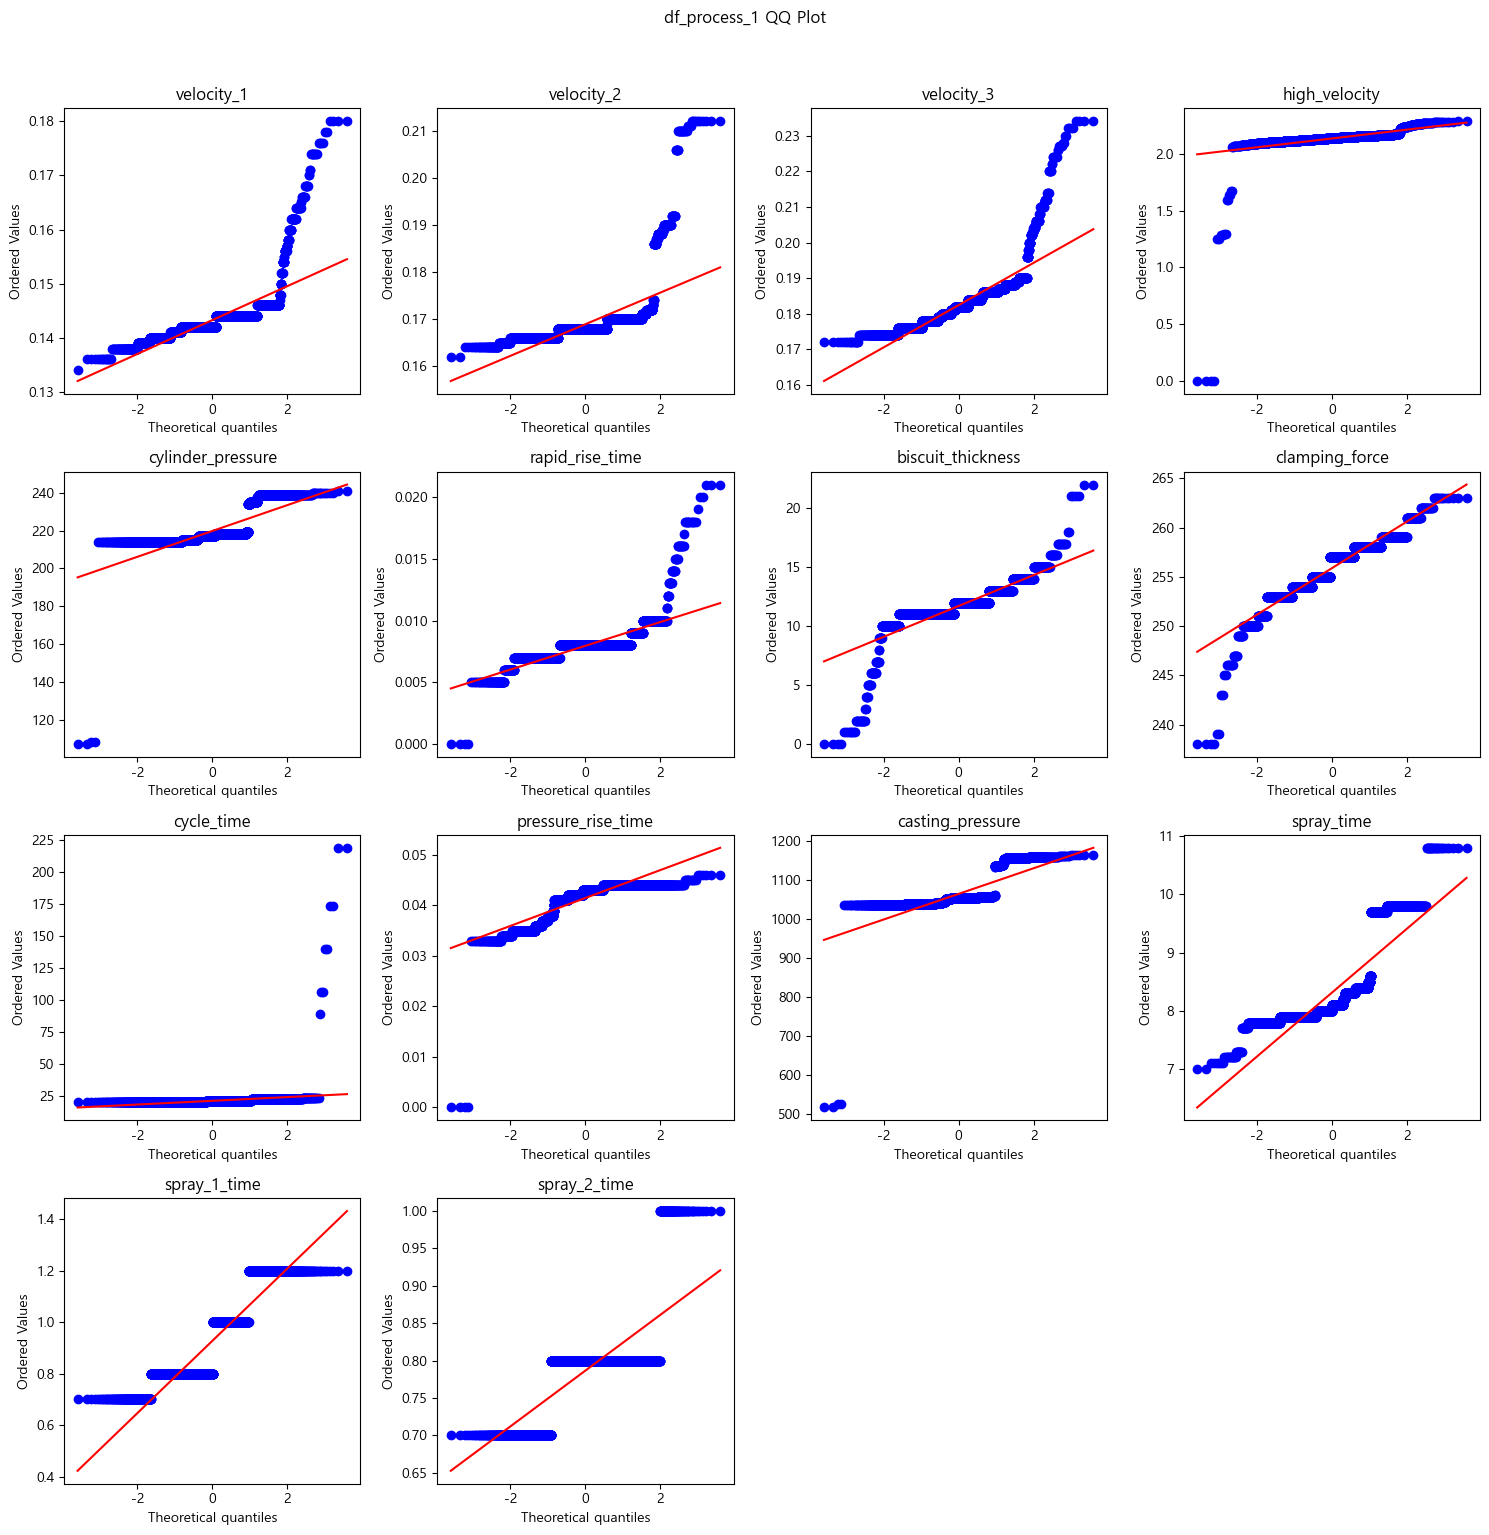

In [8]:
plot_qq_table(df_process_1, title="df_process_1 QQ Plot")

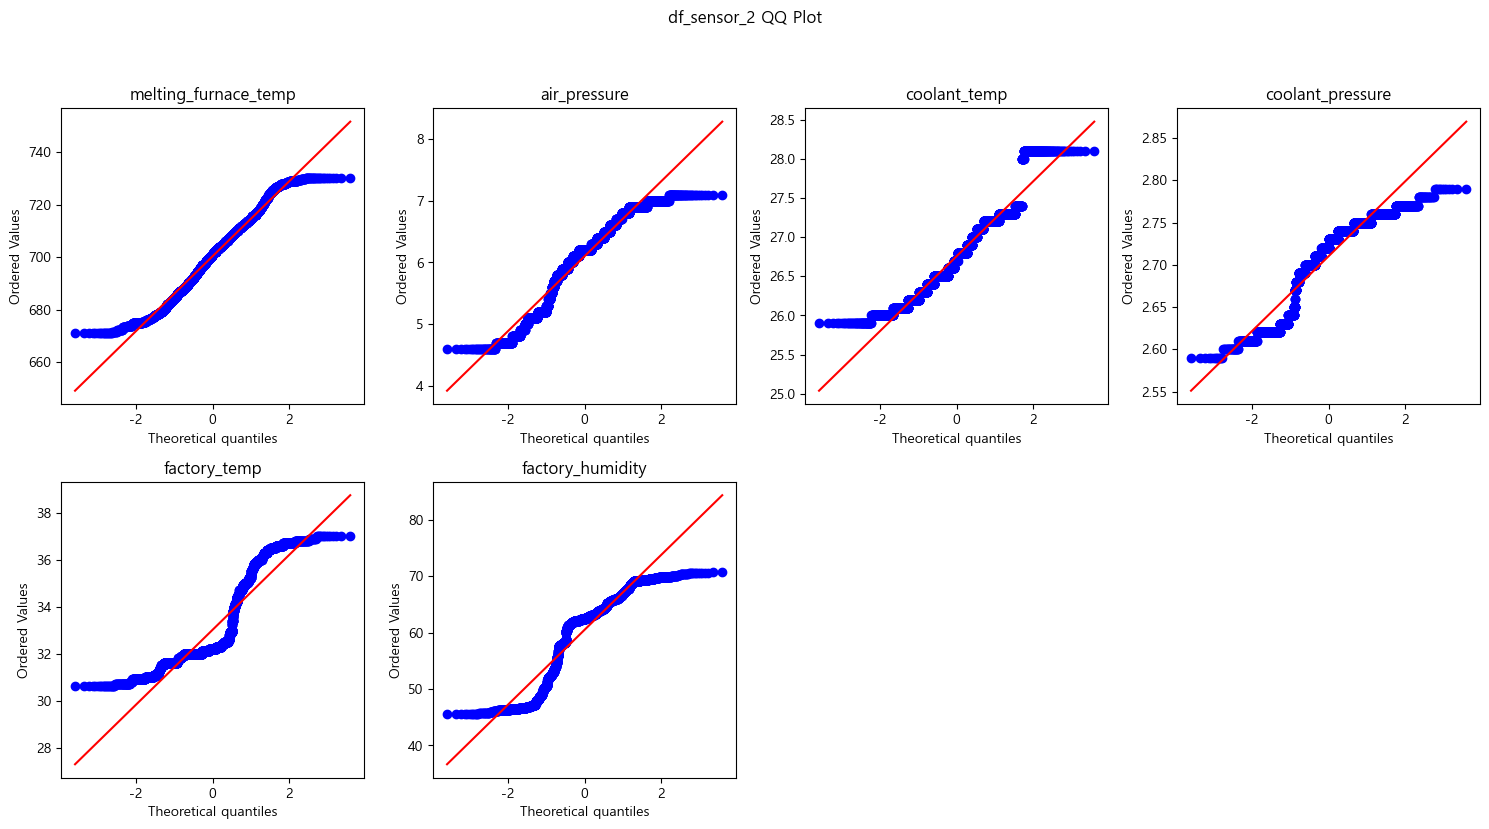

In [9]:
plot_qq_table(df_sensor_1, title="df_sensor_2 QQ Plot")

#### 2.3 Levene 검증

In [10]:
# 연속형 변수 등분산성 검정 (Levene test)
def create_levene_summary(features_df, defects_df, target_col, df_name, exclude_cols=None, alpha=0.05):
    
    print(f"\n{'='*80}")
    print(f"{df_name} 연속형 변수 등분산성 검정 (Levene test) - 기준: {target_col}")
    print(f"{'='*80}\n")
    
    # exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = features_df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 기준 타깃 시리즈 가져오기
    target_series = defects_df[target_col]
    
    result_list = []
    
    # 각 컬럼별 등분산성 검정
    for col in df_copied.columns:
        group_0 = df_copied[target_series == 0][col].dropna()
        group_1 = df_copied[target_series == 1][col].dropna()
        
        stat, p_value = stats.levene(group_0, group_1)
        
        if p_value >= alpha:
            result = "등분산 만족"
        else:
            result = "등분산 불만족"
        
        result_list.append([col, stat, p_value, result])
    
    # 결과표 생성
    levene_df = pd.DataFrame(
        result_list,
        columns=["변수명", "Levene 통계량", "p-value", "판정"]
    )
    levene_df = levene_df.set_index("변수명")
    
    display(levene_df)
    
    return levene_df

In [11]:
process_levene_surface = create_levene_summary(
    df_process_1,
    df_defects_1_1,
    "is_defect",
    "df_process_1",
    exclude_cols=['shot_key']
)


df_process_1 연속형 변수 등분산성 검정 (Levene test) - 기준: is_defect



,Levene 통계량,p-value,판정
변수명,,,
velocity_1,21.089683,4.510936e-06,등분산 불만족
velocity_2,27.120408,2.003106e-07,등분산 불만족
velocity_3,26.808306,2.351704e-07,등분산 불만족
high_velocity,11.845690,5.835823e-04,등분산 불만족
cylinder_pressure,137.526513,2.825283e-31,등분산 불만족
rapid_rise_time,7.655019,5.686208e-03,등분산 불만족
biscuit_thickness,62.364014,3.615832e-15,등분산 불만족
clamping_force,51.845692,7.077913e-13,등분산 불만족
cycle_time,0.460697,4.973358e-01,등분산 만족


In [12]:
process_levene_surface = create_levene_summary(
    df_sensor_1,
    df_defects_1_1,
    "is_defect",
    "df_sensor_1",
)


df_sensor_1 연속형 변수 등분산성 검정 (Levene test) - 기준: is_defect



,Levene 통계량,p-value,판정
변수명,,,
melting_furnace_temp,31.602239,2.014701e-08,등분산 불만족
air_pressure,153.085205,1.456104e-34,등분산 불만족
coolant_temp,15.763107,7.298812e-05,등분산 불만족
coolant_pressure,123.729716,2.391456e-28,등분산 불만족
factory_temp,239.109585,1.672580e-52,등분산 불만족
factory_humidity,153.783089,1.037631e-34,등분산 불만족


#### 상관계수 히트맵

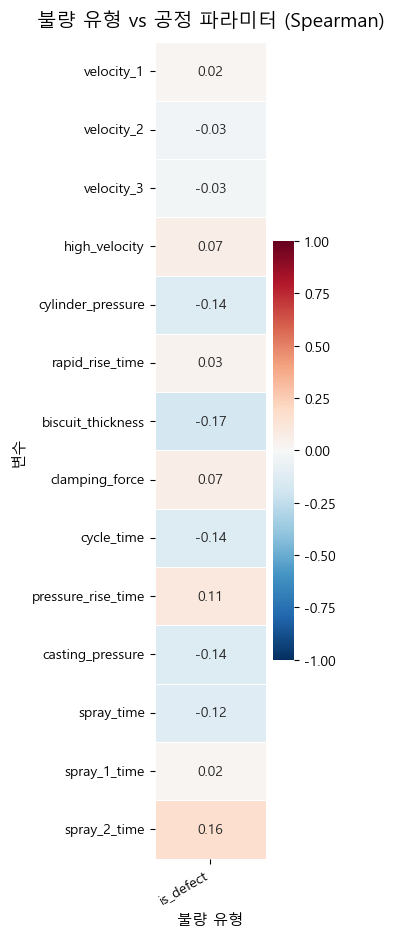

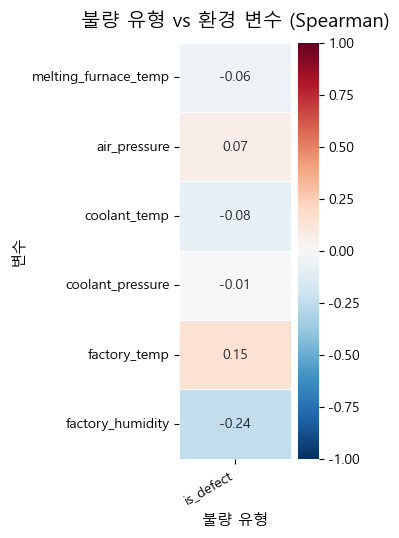

In [13]:
#DEFECT_COLS = [
#    'surface_defect',
#    'structural_defect',
#    'contamination_defect'
#]

DE = ['is_defect']

PROCESS_COLS = [
    'velocity_1', 'velocity_2', 'velocity_3', 'high_velocity',
    'cylinder_pressure', 'rapid_rise_time', 'biscuit_thickness',
    'clamping_force', 'cycle_time', 'pressure_rise_time',
    'casting_pressure', 'spray_time', 'spray_1_time', 'spray_2_time',
]

SENSOR_COLS = [
    'melting_furnace_temp', 'air_pressure', 'coolant_temp', 'coolant_pressure',
    'factory_temp', 'factory_humidity'
]

# 함수
def plot_corr_heatmap(df, defect_cols, feature_cols, title):
    corr = df[defect_cols + feature_cols].corr(method='spearman')
    corr_target = corr.loc[feature_cols, defect_cols]

    fig, ax = plt.subplots(
        figsize=(len(defect_cols) * 1.8, len(feature_cols) * 0.65 + 1.5)
    )

    sns.heatmap(
        corr_target,
        annot=True,
        fmt='.2f',
        cmap='RdBu_r',
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.5,
        ax=ax
    )

    ax.set_title(title, fontsize=14, pad=12)
    ax.set_xlabel('불량 유형', fontsize=11)
    ax.set_ylabel('변수', fontsize=11)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

# 출력
plot_corr_heatmap(df_original_1_1, DE, PROCESS_COLS, '불량 유형 vs 공정 파라미터 (Spearman)')
plot_corr_heatmap(df_original_1_1, DE, SENSOR_COLS, '불량 유형 vs 환경 변수 (Spearman)')

---
---
#### 2.5 개인적으로 확인해보는 즁

In [14]:
# 1. 샘플 수 & 불량률
total    = len(df_original_1_1)
n_defect = df_original_1_1["is_defect"].sum() # 불량제품
n_normal = total - n_defect # 정상 제품
rate     = n_defect / total * 100

print(f"\n=== 기초 현황 ===")
print(f"전체 샘플 : {total:,}개")
print(f"불량      : {int(n_defect):,}개")
print(f"정상      : {int(n_normal):,}개")
print(f"불량률    : {rate:.2f}%")

# 2. 결측치 확인
print("\n=== 결측치 ===")
print(df_original_1_1.isnull().sum())


=== 기초 현황 ===
전체 샘플 : 4,207개
불량      : 739개
정상      : 3,468개
불량률    : 17.57%

=== 결측치 ===
shot_key                0
velocity_1              0
velocity_2              0
velocity_3              0
high_velocity           0
cylinder_pressure       0
rapid_rise_time         0
biscuit_thickness       0
clamping_force          0
cycle_time              0
pressure_rise_time      0
casting_pressure        0
spray_time              0
spray_1_time            0
spray_2_time            0
melting_furnace_temp    0
air_pressure            0
coolant_temp            0
coolant_pressure        0
factory_temp            0
factory_humidity        0
is_defect               0
dtype: int64


In [15]:
# 박스플롯 함수
import math

def plot_boxplots(df, cols, group_title):
    
    # is_defect를 문자열로 변환
    df_a = df.copy()
    df_a["is_defect"] = df["is_defect"].map({0: "정상", 1: "불량"})
    
    n_rows = math.ceil(len(cols) / 4)  # 올림 나눗셈

    fig, axes = plt.subplots(n_rows, 4, figsize=(20, n_rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        sns.boxplot(
            x="is_defect", y=col,
            data=df_a,
            palette={"정상": "#4C72B0", "불량": "#DD8452"},
            ax=axes[i]
        )
        axes[i].set_title(col, fontsize=11, fontweight="bold")
        axes[i].set_xlabel("")
        axes[i].set_xticklabels(["정상", "불량"], fontsize=10)

    # 빈 subplot 숨기기
    for j in range(len(cols), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"[{group_title}] 정상 vs 불량 분포 비교", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()
    
    return df_a

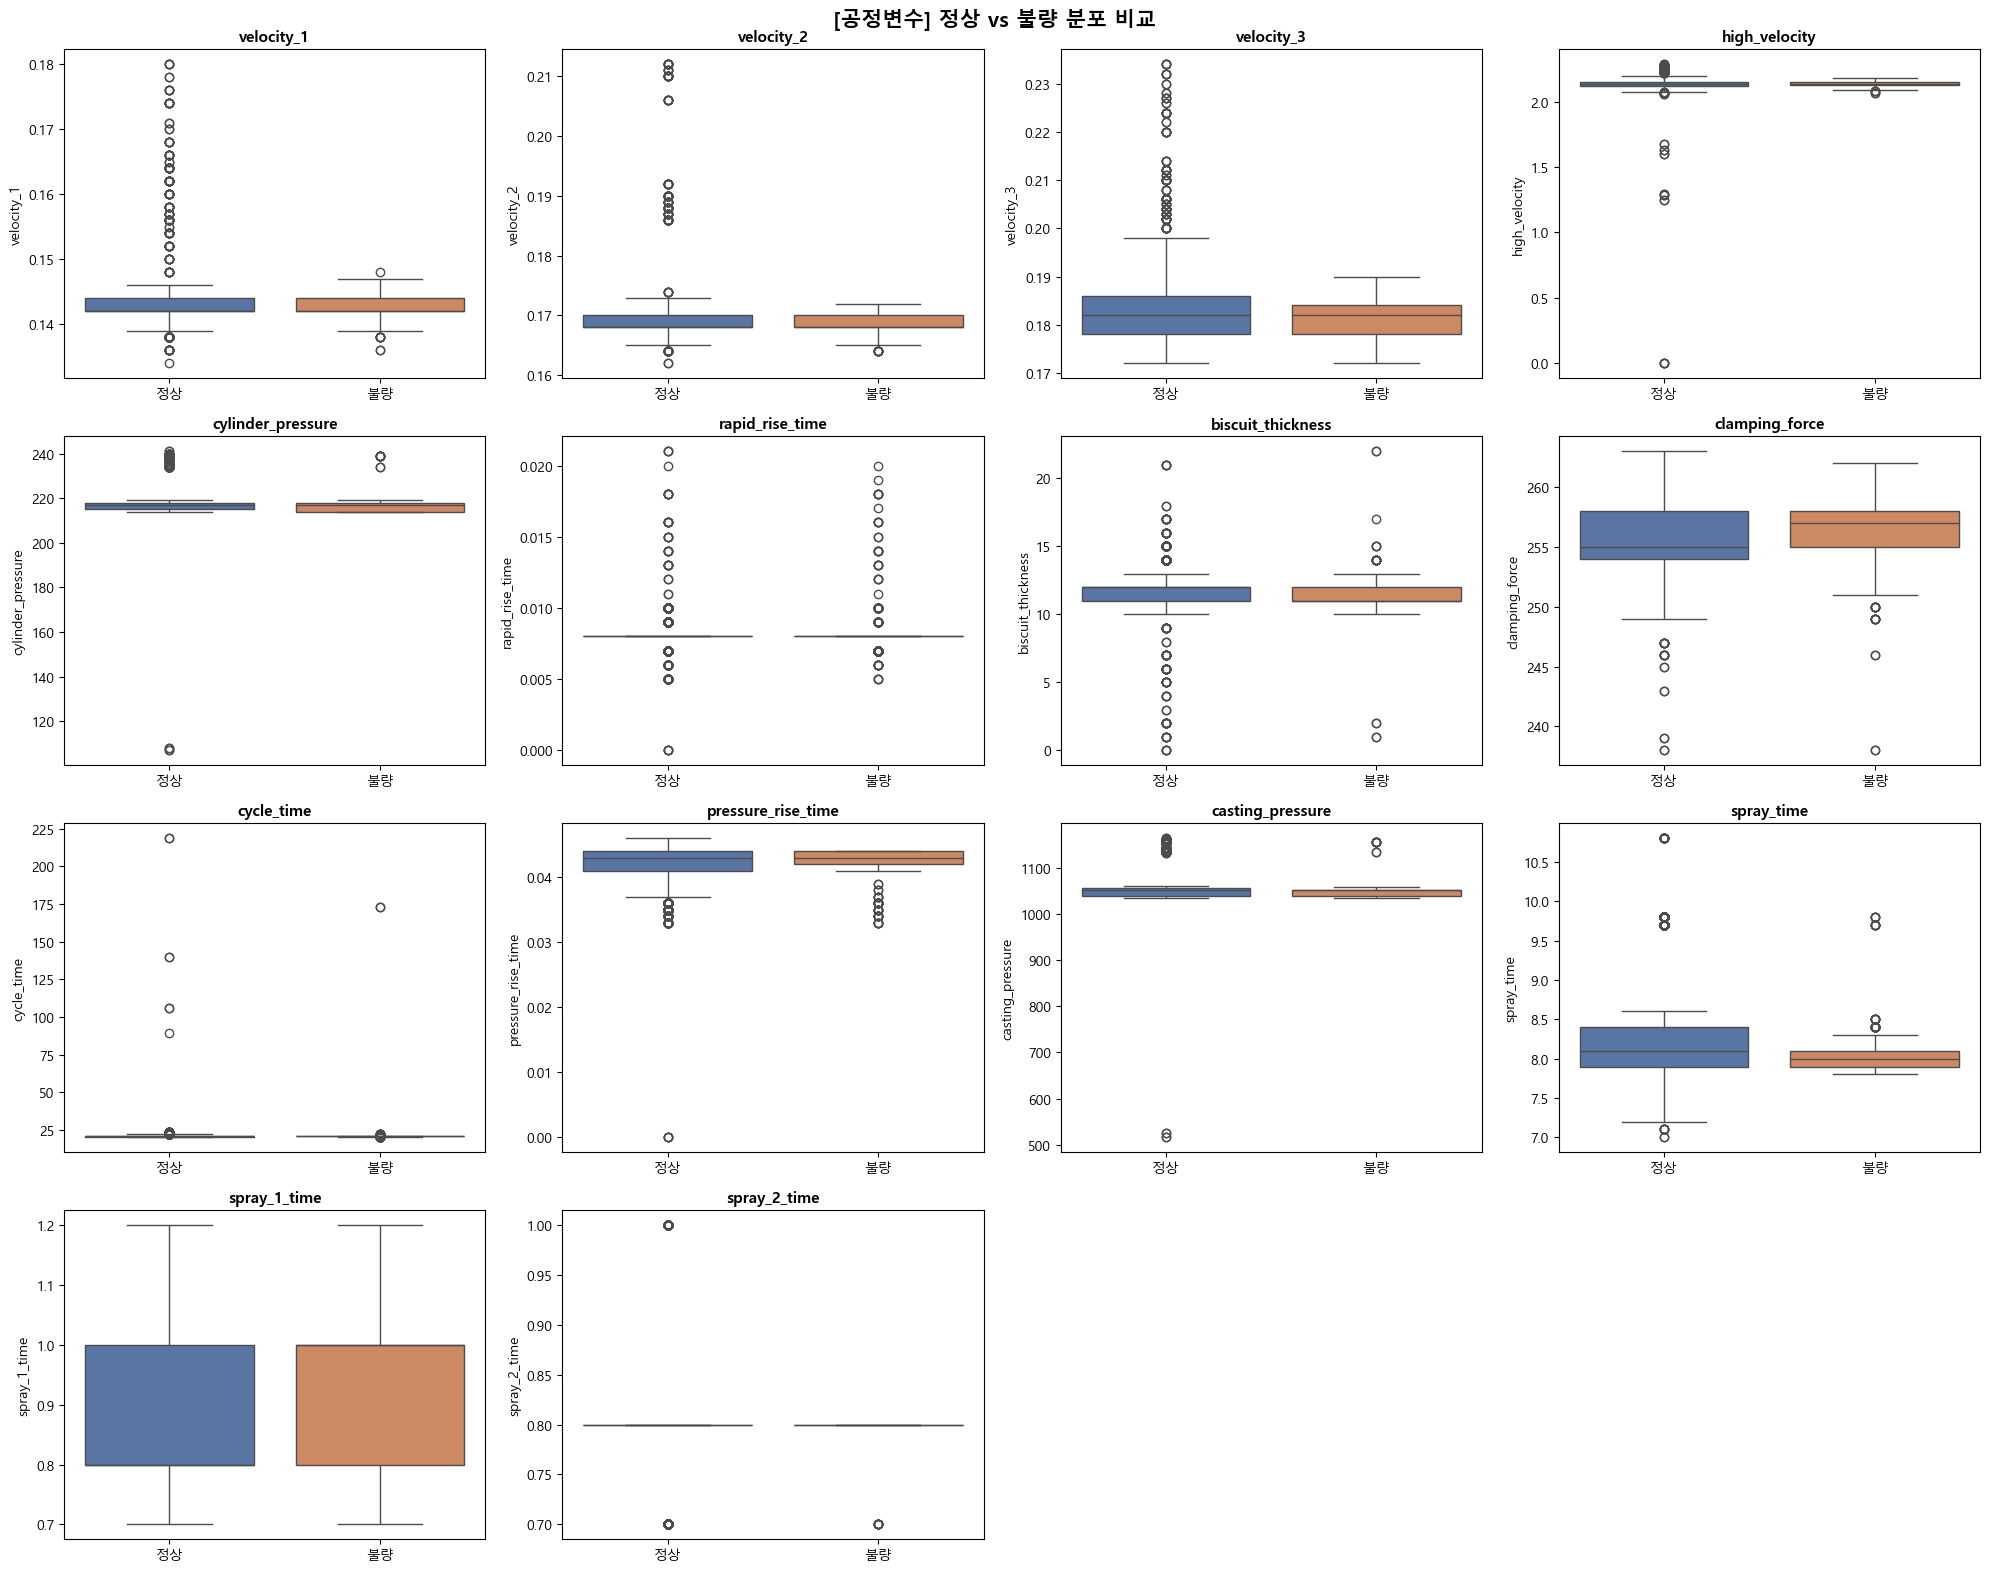

In [16]:
# process 관련 변수의 박스플롯
boxplot_of_process_1 = plot_boxplots(df_original_1_1, PROCESS_COLS, "공정변수")

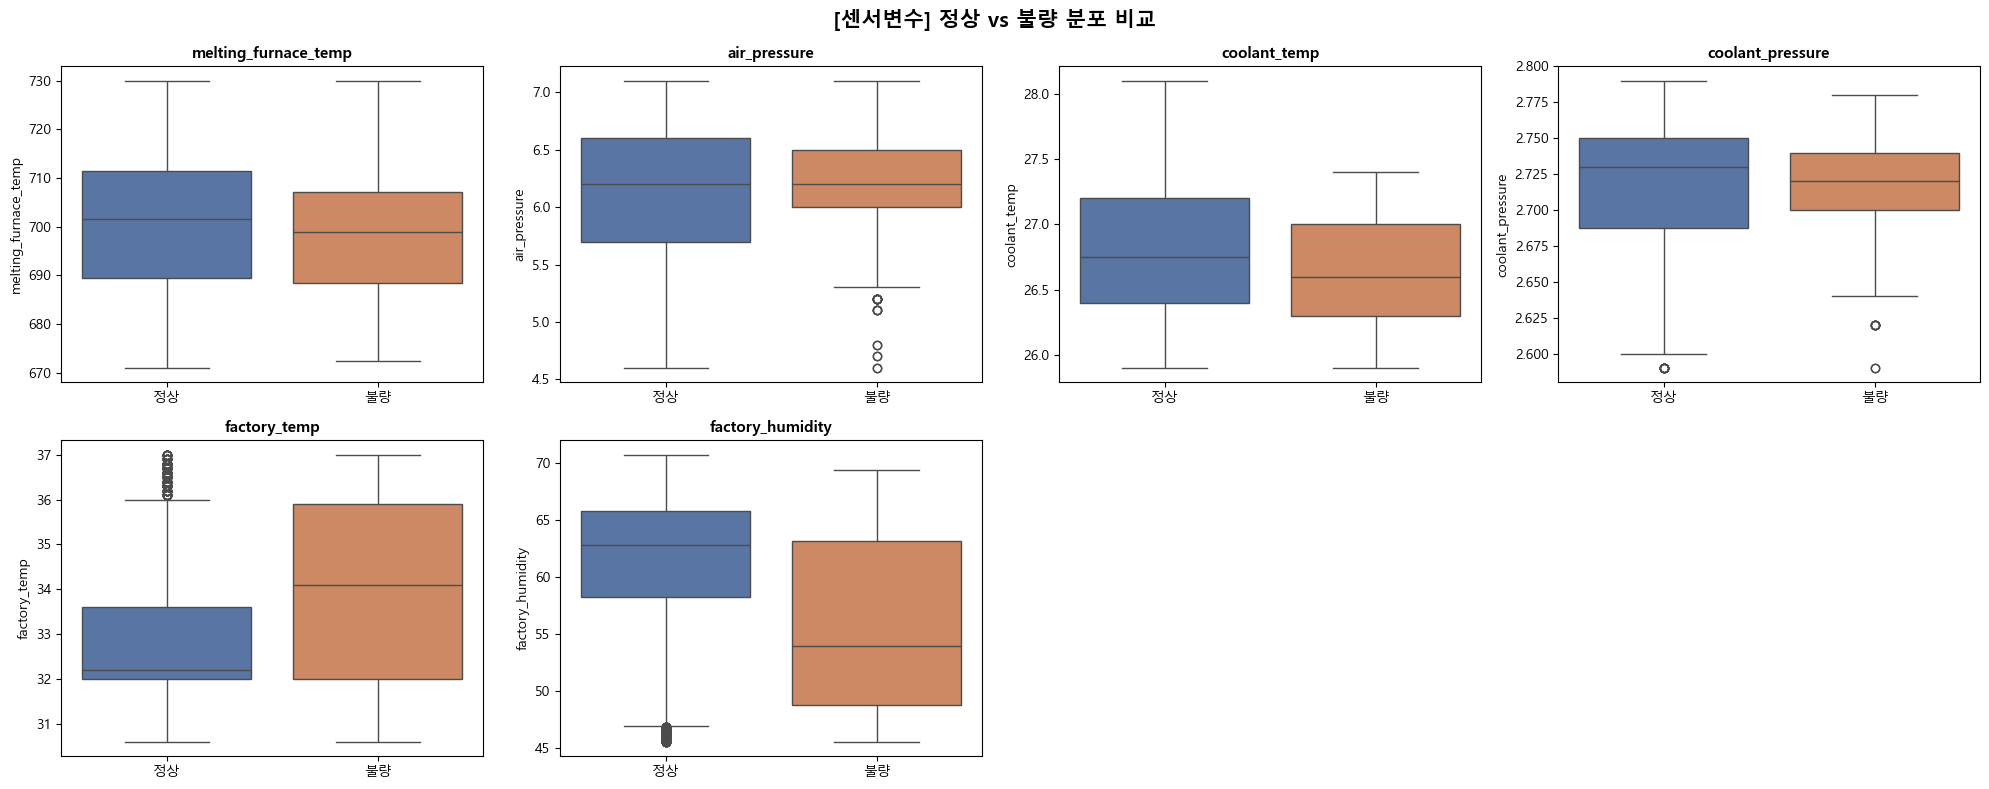

In [17]:
boxplot_of_sensor_1 = plot_boxplots(df_original_1_1, SENSOR_COLS, "센서변수")

- 박스플롯을 본 이유는 정상일 때와 불량일 때, 각각의 변수의 분포가 어떤지 궁금해서 확인해본 것
- 분포가 너무 많이 다르면 불량에 영향을 줬을지도 모르니까
- 분포가 완전히 다르게 형성된다면 그것도 그거 나름대로 의미가 있을수도 있지 않을까 싶어서
- 만약에 분포가 비슷하다면 어떤 이상치가 많은지도 궁금해서

In [18]:
print("정상 제품의 기술통계량")
df_original_1_1[df_original_1_1["is_defect"] == 0].describe().T

정상 제품의 기술통계량


,count,mean,std,min,25%,50%,75%,max
velocity_1,3468.0,0.143364,0.004488,0.134,0.1420,0.142,0.144,0.180
velocity_2,3468.0,0.169134,0.005667,0.162,0.1680,0.168,0.170,0.212
velocity_3,3468.0,0.182658,0.007289,0.172,0.1780,0.182,0.186,0.234
high_velocity,3468.0,2.133144,0.089081,0.000,2.1190,2.136,2.151,2.285
cylinder_pressure,3468.0,220.483852,9.548989,107.000,215.0000,217.000,218.000,241.000
rapid_rise_time,3468.0,0.007921,0.001176,0.000,0.0080,0.008,0.008,0.021
biscuit_thickness,3468.0,11.783449,1.587408,0.000,11.0000,12.000,12.000,21.000
clamping_force,3468.0,255.807958,2.495806,238.000,254.0000,255.000,258.000,263.000
cycle_time,3468.0,21.462832,6.044495,20.200,20.7000,20.900,21.300,218.600
pressure_rise_time,3468.0,0.041296,0.003419,0.000,0.0410,0.043,0.044,0.046


In [19]:
print("불량제품의 기술통계량")
df_original_1_1[df_original_1_1["is_defect"] == 1].describe().T

불량제품의 기술통계량


,count,mean,std,min,25%,50%,75%,max
velocity_1,739.0,0.142842,0.001827,0.136,0.142,0.142,0.144,0.148
velocity_2,739.0,0.168050,0.001554,0.164,0.168,0.168,0.170,0.172
velocity_3,739.0,0.181465,0.004085,0.172,0.178,0.182,0.184,0.190
high_velocity,739.0,2.138438,0.018146,2.066,2.126,2.138,2.153,2.178
cylinder_pressure,739.0,216.552097,3.029830,214.000,214.000,217.000,218.000,239.000
rapid_rise_time,739.0,0.008164,0.001612,0.005,0.008,0.008,0.008,0.020
biscuit_thickness,739.0,11.395129,1.173685,1.000,11.000,11.000,12.000,22.000
clamping_force,739.0,256.201624,2.290240,238.000,255.000,257.000,258.000,262.000
cycle_time,739.0,21.287957,7.912765,20.400,20.800,20.800,20.900,173.000
pressure_rise_time,739.0,0.042414,0.002117,0.033,0.042,0.043,0.044,0.044


In [31]:
def interpret_cohens_d(d):
    if d < 0.1:   
        return "매우 작음"
    elif d < 0.3: 
        return "작음"
    elif d < 0.5:
        return "중간"
    else:         
        return "큼"

In [32]:
# Welch's t-test

ALL_COLS = PROCESS_COLS + SENSOR_COLS

result = []

alpha = 0.05

for col in ALL_COLS:
    g0 = df_original_1_1.loc[df_original_1_1["is_defect"] == 0, col]
    g1 = df_original_1_1.loc[df_original_1_1["is_defect"] == 1, col]
    
    t_stat, p_val = stats.ttest_ind(g0, g1, equal_var=False)
    
    # Cohen's d
    pooled_std = np.sqrt((g0.std()**2 + g1.std()**2) / 2)
    cohens_d   = (g1.mean() - g0.mean()) / pooled_std
    
    result.append({
        "요인":       col,
        "정상 제품의 평균": round(g0.mean(), 4),
        "불량 제품의 평균": round(g1.mean(), 4),
        "t-통계량": round(t_stat, 4),
        "Cohen's d": round(cohens_d, 4),
        "효과크기 해석": interpret_cohens_d(abs(cohens_d)),
        "p-value": float(f"{p_val:.4e}"),
    })

df_welchs = pd.DataFrame(result)

df_welchs['통계적 유의성 여부'] = df_welchs['p-value'] < alpha

display(df_welchs)

,요인,정상 제품의 평균,불량 제품의 평균,t-통계량,Cohen's d,효과크기 해석,p-value,통계적 유의성 여부
0,velocity_1,0.1434,0.1428,5.1358,-0.1523,작음,2.998100e-07,True
1,velocity_2,0.1691,0.1681,9.6845,-0.2609,작음,6.099100e-22,True
2,velocity_3,0.1827,0.1815,6.1259,-0.2018,작음,1.094100e-09,True
3,high_velocity,2.1331,2.1384,-3.2022,0.0824,매우 작음,1.374000e-03,True
4,cylinder_pressure,220.4839,216.5521,19.9824,-0.5550,큼,2.077400e-84,True
5,rapid_rise_time,0.0079,0.0082,-3.8847,0.1723,작음,1.098400e-04,True
6,biscuit_thickness,11.7834,11.3951,7.6293,-0.2782,작음,4.375300e-14,True
7,clamping_force,255.8080,256.2016,-4.1743,0.1644,작음,3.216100e-05,True
8,cycle_time,21.4628,21.2880,0.5666,-0.0248,매우 작음,5.711300e-01,False
9,pressure_rise_time,0.0413,0.0424,-11.5147,0.3933,중간,1.394700e-29,True


In [33]:
def interpret_rbc(r):
    if r < 0.1:   
        return "매우 작음"
    elif r < 0.3: 
        return "작음"
    elif r < 0.5: 
        return "중간"
    else:         
        return "큼"

In [34]:
# Mann-Whitney U
result_mwu = []
for col in ALL_COLS:
    g0 = df_original_1_1.loc[df_original_1_1["is_defect"] == 0, col]
    g1 = df_original_1_1.loc[df_original_1_1["is_defect"] == 1, col]
    
    u_stat, p_val = stats.mannwhitneyu(g0, g1, alternative="two-sided")
    
    # Rank-biserial correlation (효과 크기)
    r_rbc = 1 - (2 * u_stat) / (len(g0) * len(g1))
    
    result_mwu.append({
        "요인":            col,
        "U-통계량":        round(u_stat, 4),
        "rank-biserial r": round(r_rbc, 4),
        "효과크기 해석": interpret_rbc(abs(r_rbc)),
        "p-value":         float(f"{p_val:.4e}"),
    })

df_mwu = pd.DataFrame(result_mwu)

df_mwu["통계적 유의성 여부"] = df_mwu["p-value"] < alpha

display(df_mwu)

,요인,U-통계량,rank-biserial r,효과크기 해석,p-value,통계적 유의성 여부
0,velocity_1,1245130.5,0.0283,매우 작음,2.065900e-01,False
1,velocity_2,1339108.0,-0.0450,매우 작음,3.873300e-02,True
2,velocity_3,1336305.0,-0.0428,매우 작음,6.569900e-02,False
3,high_velocity,1153846.0,0.0996,매우 작음,2.078600e-05,True
4,cylinder_pressure,1539452.0,-0.2014,작음,1.476000e-18,True
5,rapid_rise_time,1224530.5,0.0444,매우 작음,2.573200e-02,True
6,biscuit_thickness,1599926.0,-0.2486,작음,3.104100e-29,True
7,clamping_force,1153419.0,0.0999,매우 작음,1.435100e-05,True
8,cycle_time,1551639.0,-0.2109,작음,9.834500e-20,True
9,pressure_rise_time,1081289.5,0.1562,작음,8.391700e-12,True


In [35]:
# 정렬할 때는 절댓값 기준으로 나열
df_mwu.sort_values('rank-biserial r', key=abs, ascending=False)

,요인,U-통계량,rank-biserial r,효과크기 해석,p-value,통계적 유의성 여부
19,factory_humidity,1752891.5,-0.3679,중간,9.742100e-56,True
6,biscuit_thickness,1599926.0,-0.2486,작음,3.104100e-29,True
18,factory_temp,988715.0,0.2284,작음,1.190100e-22,True
8,cycle_time,1551639.0,-0.2109,작음,9.834500e-20,True
10,casting_pressure,1551565.0,-0.2108,작음,1.704300e-19,True
4,cylinder_pressure,1539452.0,-0.2014,작음,1.476000e-18,True
11,spray_time,1514529.0,-0.1819,작음,3.323600e-15,True
13,spray_2_time,1057362.0,0.1749,작음,1.243900e-26,True
9,pressure_rise_time,1081289.5,0.1562,작음,8.391700e-12,True
16,coolant_temp,1434530.0,-0.1195,작음,3.002000e-07,True


---
---
#### 효과크기 해석을 기준으로 정렬 (그냥 궁금해서)

In [36]:
def sort_by_category(df, col, order, ascending=True):
    return df.sort_values(
        col,
        key=lambda x: x.map({v: i for i, v in enumerate(order)}),
        ascending=ascending
    )
    
    
order = ['큼', '중간', '작음', '매우 작음']

print("welch's T-test 결과")
sort_by_category(df_welchs, "효과크기 해석", order)

welch's T-test 결과


,요인,정상 제품의 평균,불량 제품의 평균,t-통계량,Cohen's d,효과크기 해석,p-value,통계적 유의성 여부
19,factory_humidity,61.4629,56.1440,17.6666,-0.7490,큼,6.858500e-61,True
11,spray_time,8.3676,8.0503,21.3349,-0.6066,큼,7.577500e-95,True
10,casting_pressure,1067.1592,1048.1624,20.0870,-0.5562,큼,2.833400e-85,True
4,cylinder_pressure,220.4839,216.5521,19.9824,-0.5550,큼,2.077400e-84,True
18,factory_temp,32.8432,33.8269,-12.1909,0.5302,큼,7.551800e-32,True
13,spray_2_time,0.7840,0.7986,-14.2212,0.3671,중간,7.310000e-45,True
9,pressure_rise_time,0.0413,0.0424,-11.5147,0.3933,중간,1.394700e-29,True
7,clamping_force,255.8080,256.2016,-4.1743,0.1644,작음,3.216100e-05,True
5,rapid_rise_time,0.0079,0.0082,-3.8847,0.1723,작음,1.098400e-04,True
2,velocity_3,0.1827,0.1815,6.1259,-0.2018,작음,1.094100e-09,True


In [38]:
order = ['큼', '중간', '작음', '매우 작음']

print("MWU 결과")
sort_by_category(df_mwu, "효과크기 해석", order)

MWU 결과


,요인,U-통계량,rank-biserial r,효과크기 해석,p-value,통계적 유의성 여부
19,factory_humidity,1752891.5,-0.3679,중간,9.742100e-56,True
16,coolant_temp,1434530.0,-0.1195,작음,3.002000e-07,True
15,air_pressure,1150729.5,0.1020,작음,1.247700e-05,True
13,spray_2_time,1057362.0,0.1749,작음,1.243900e-26,True
11,spray_time,1514529.0,-0.1819,작음,3.323600e-15,True
10,casting_pressure,1551565.0,-0.2108,작음,1.704300e-19,True
18,factory_temp,988715.0,0.2284,작음,1.190100e-22,True
8,cycle_time,1551639.0,-0.2109,작음,9.834500e-20,True
9,pressure_rise_time,1081289.5,0.1562,작음,8.391700e-12,True
6,biscuit_thickness,1599926.0,-0.2486,작음,3.104100e-29,True
